## dataloader

In [2]:
import sys

sys.path.insert(0, "../src")

import logging

from dataloader import SubjectWiseDataLoader, load_dataset

logging.basicConfig(level=logging.INFO)

# ── Method 1: Using the SubjectWiseDataLoader class ──────────────────────────
loader = SubjectWiseDataLoader()
splits = loader.prepare()

# Get train/val/test splits as DataFrames
train_df = loader.get_split("train")
val_df = loader.get_split("val")
test_df = loader.get_split("test")

print("\n" + "=" * 60)
print("DATALOADER SUMMARY")
print("=" * 60)
print(f"Features used: {loader.feature_cols}")
print(f"Target column: {loader.target_col}")

# Get as numpy arrays for model training
train_X, train_y = loader.get_split("train", return_arrays=True)
val_X, val_y = loader.get_split("val", return_arrays=True)
test_X, test_y = loader.get_split("test", return_arrays=True)

print(f"\nTrain: X shape {train_X.shape}, y shape {train_y.shape}")
print(f"Val:   X shape {val_X.shape}, y shape {val_y.shape}")
print(f"Test:  X shape {test_X.shape}, y shape {test_y.shape}")

print("\n" + "=" * 60)
print("Label distribution in each split:")
print("=" * 60)
for split_name in ["train", "val", "test"]:
    df = splits[split_name]
    label_counts = df["pseudo_label_smoothed"].value_counts().sort_index()
    print(f"{split_name}: {dict(label_counts)} (total: {len(df)})")

INFO:dataloader:Loaded dataset: 2541 rows, 31 columns
INFO:dataloader:Found 24 unique subjects
INFO:dataloader:Splitting 24 subjects into train/val/test...
INFO:dataloader:train: 2015 rows (79.3%), 18 subjects (75.0%), labels: {0: 1283, 1: 732}
INFO:dataloader:val: 48 rows (1.9%), 3 subjects (12.5%), labels: {0: 29, 1: 19}
INFO:dataloader:test: 478 rows (18.8%), 3 subjects (12.5%), labels: {0: 304, 1: 174}



DATALOADER SUMMARY
Features used: ['sdnn_znorm', 'cv_rr_znorm', 'rmssd_znorm', 'pnn50_znorm']
Target column: pseudo_label_smoothed

Train: X shape (2015, 4), y shape (2015,)
Val:   X shape (48, 4), y shape (48,)
Test:  X shape (478, 4), y shape (478,)

Label distribution in each split:
train: {0: np.int64(1283), 1: np.int64(732)} (total: 2015)
val: {0: np.int64(29), 1: np.int64(19)} (total: 48)
test: {0: np.int64(304), 1: np.int64(174)} (total: 478)


In [3]:
# ── Method 2: Using the convenience function ────────────────────────────────
import numpy as np

splits_alt, features = load_dataset()

print("\n" + "=" * 60)
print("ALTERNATIVE: Using load_dataset() convenience function")
print("=" * 60)
print(f"Features: {features}")
print(f"Train rows: {len(splits_alt['train'])}")
print(f"Val rows: {len(splits_alt['val'])}")
print(f"Test rows: {len(splits_alt['test'])}")

# ── Method 3: Get all splits as numpy arrays at once ────────────────────────
all_splits_arrays = loader.get_all_splits(return_arrays=True)

print("\n" + "=" * 60)
print("NUMPY ARRAYS: Ready for model training")
print("=" * 60)
for split_name, (X, y) in all_splits_arrays.items():
    print(f"{split_name}: X {X.shape} (float32), y {y.shape} (int64)")
    print(f"  -> y classes: {np.unique(y)}, class ratio: {np.bincount(y)}")

INFO:dataloader:Loaded dataset: 2541 rows, 31 columns
INFO:dataloader:Found 24 unique subjects
INFO:dataloader:Splitting 24 subjects into train/val/test...
INFO:dataloader:train: 2015 rows (79.3%), 18 subjects (75.0%), labels: {0: 1283, 1: 732}
INFO:dataloader:val: 48 rows (1.9%), 3 subjects (12.5%), labels: {0: 29, 1: 19}
INFO:dataloader:test: 478 rows (18.8%), 3 subjects (12.5%), labels: {0: 304, 1: 174}



ALTERNATIVE: Using load_dataset() convenience function
Features: ['sdnn_znorm', 'cv_rr_znorm', 'rmssd_znorm', 'pnn50_znorm']
Train rows: 2015
Val rows: 48
Test rows: 478

NUMPY ARRAYS: Ready for model training
train: X (2015, 4) (float32), y (2015,) (int64)
  -> y classes: [0 1], class ratio: [1283  732]
val: X (48, 4) (float32), y (48,) (int64)
  -> y classes: [0 1], class ratio: [29 19]
test: X (478, 4) (float32), y (478,) (int64)
  -> y classes: [0 1], class ratio: [304 174]


In [4]:
# noqa: E402, W293, E501
# ── Leave-One-Subject-Out (LOSO) Cross-Validation ────────────────────────

from dataloader import load_loso_folds

print("\n" + "=" * 60)
print("LOSO CROSS-VALIDATION")
print("=" * 60)

# Get LOSO folds
folds, features = load_loso_folds()
print(f"\nTotal folds: {len(folds)} (one subject left out per fold)")
print(f"Features: {features}")

# Display fold statistics
print("\nFold breakdown (first 5 and last 2):")
for fold_idx in list(range(5)) + list(range(len(folds) - 2, len(folds))):
    if fold_idx < len(folds):
        fold = folds[fold_idx]
        test_subj = fold["test"]["subject_id"].iloc[0]
        train_n = len(fold["train"])
        test_n = len(fold["test"])
        train_subj = fold["train"]["subject_id"].nunique()

        y_train = fold["train"]["pseudo_label_smoothed"]
        y_test = fold["test"]["pseudo_label_smoothed"]

        print(
            f"  Fold {fold_idx:2d}: left_out={test_subj:12s} | "
            f"train: {train_n:4d} rows ({train_subj} subj) | "
            f"test: {test_n:3d} rows | "
            f"train_labels: {dict(y_train.value_counts().sort_index())}"
        )

# Example: train and evaluate on all folds
print("\n" + "=" * 60)
print("USAGE EXAMPLE: Model Training Loop")
print("=" * 60)

print("\n# Template for cross-validation training:")
template = """
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score
)

folds, features = load_loso_folds()
metrics_per_fold = []

for fold_idx, fold in enumerate(folds):
    # Extract train/test data
    X_train = fold['train'][features].values
    y_train = fold['train']['pseudo_label_smoothed'].values
    X_test = fold['test'][features].values
    y_test = fold['test']['pseudo_label_smoothed'].values

    # Preprocess
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Train and evaluate
    model = LogisticRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Metrics
    metrics = {
        'fold': fold_idx,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
    }
    metrics_per_fold.append(metrics)
    print(f"Fold {fold_idx}: acc={metrics['accuracy']:.3f}, "
          f"f1={metrics['f1']:.3f}")

# Average across folds
import pandas as pd
results_df = pd.DataFrame(metrics_per_fold)
avg_acc = results_df['accuracy'].mean()
std_acc = results_df['accuracy'].std()
avg_f1 = results_df['f1'].mean()
std_f1 = results_df['f1'].std()
print(f"Average Accuracy: {avg_acc:.3f} ± {std_acc:.3f}")
print(f"Average F1-Score: {avg_f1:.3f} ± {std_f1:.3f}")
"""
print(template)

INFO:dataloader:Loaded dataset: 2541 rows, 31 columns
INFO:dataloader:Found 24 unique subjects
INFO:dataloader:Creating LOSO folds with 24 subjects...


INFO:dataloader:Fold  1/24: test_subject=ddd_01M, train_samples=2307, test_samples=234
INFO:dataloader:Fold  2/24: test_subject=ddd_02F, train_samples=2305, test_samples=236
INFO:dataloader:Fold  3/24: test_subject=ddd_03F, train_samples=2306, test_samples=235
INFO:dataloader:Fold  4/24: test_subject=ddd_04M, train_samples=2314, test_samples=227
INFO:dataloader:Fold  5/24: test_subject=ddd_05M, train_samples=2309, test_samples=232
INFO:dataloader:Fold  6/24: test_subject=ddd_06M, train_samples=2307, test_samples=234
INFO:dataloader:Fold  7/24: test_subject=ddd_07F, train_samples=2307, test_samples=234
INFO:dataloader:Fold  8/24: test_subject=ddd_08M, train_samples=2309, test_samples=232
INFO:dataloader:Fold  9/24: test_subject=ddd_09M, train_samples=2309, test_samples=232
INFO:dataloader:Fold 10/24: test_subject=ddd_10M, train_samples=2309, test_samples=232
INFO:dataloader:Fold 11/24: test_subject=drozy_s01, train_samples=2523, test_samples=18
INFO:dataloader:Fold 12/24: test_subject=d


LOSO CROSS-VALIDATION


INFO:dataloader:Fold 16/24: test_subject=drozy_s06, train_samples=2526, test_samples=15
INFO:dataloader:Fold 17/24: test_subject=drozy_s07, train_samples=2529, test_samples=12
INFO:dataloader:Fold 18/24: test_subject=drozy_s08, train_samples=2523, test_samples=18
INFO:dataloader:Fold 19/24: test_subject=drozy_s09, train_samples=2529, test_samples=12
INFO:dataloader:Fold 20/24: test_subject=drozy_s10, train_samples=2529, test_samples=12
INFO:dataloader:Fold 21/24: test_subject=drozy_s11, train_samples=2523, test_samples=18
INFO:dataloader:Fold 22/24: test_subject=drozy_s12, train_samples=2535, test_samples=6
INFO:dataloader:Fold 23/24: test_subject=drozy_s13, train_samples=2529, test_samples=12
INFO:dataloader:Fold 24/24: test_subject=drozy_s14, train_samples=2523, test_samples=18



Total folds: 24 (one subject left out per fold)
Features: ['sdnn_znorm', 'cv_rr_znorm', 'rmssd_znorm', 'pnn50_znorm']

Fold breakdown (first 5 and last 2):
  Fold  0: left_out=ddd_01M      | train: 2307 rows (23 subj) | test: 234 rows | train_labels: {0: np.int64(1480), 1: np.int64(827)}
  Fold  1: left_out=ddd_02F      | train: 2305 rows (23 subj) | test: 236 rows | train_labels: {0: np.int64(1489), 1: np.int64(816)}
  Fold  2: left_out=ddd_03F      | train: 2306 rows (23 subj) | test: 235 rows | train_labels: {0: np.int64(1467), 1: np.int64(839)}
  Fold  3: left_out=ddd_04M      | train: 2314 rows (23 subj) | test: 227 rows | train_labels: {0: np.int64(1480), 1: np.int64(834)}
  Fold  4: left_out=ddd_05M      | train: 2309 rows (23 subj) | test: 232 rows | train_labels: {0: np.int64(1453), 1: np.int64(856)}
  Fold 22: left_out=drozy_s13    | train: 2529 rows (23 subj) | test:  12 rows | train_labels: {0: np.int64(1608), 1: np.int64(921)}
  Fold 23: left_out=drozy_s14    | train: 252

## Bayesian Hyperparameter Optimization

In [6]:
import sys

sys.path.insert(0, "../src")
from bayesian_hpo import tune_catboost, tune_xgboost

# Example: Bayesian HPO for XGBoost with fixed split (demo with 5 trials)
# Full optimization would use n_trials=100+ and take several minutes
print("XGBoost Bayesian Optimization Example")
print("=" * 50)
print("This demonstrates how to use the tune_xgboost() function")
print("For production, use n_trials=100+ for better results")

# Example for CatBoost (not running to save time in demo)
print("\nCatBoost Bayesian Optimization Example")
print("=" * 50)
print("Similarly, tune_catboost(loader, n_trials=100, loso=False)")
print("supports both fixed split and LOSO cross-validation modes")

# For LOSO cross-validation:
print("\nLOSO Cross-Validation Mode")
print("=" * 50)
print("tune_xgboost(loader, n_trials=100, loso=True)")
print("- Evaluates hyperparameters on each LOSO fold")
print("- More robust but slower than fixed split")

c:\Users\moris\OneDrive\Documents\hackathon_blr\drowsiness-detection\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


XGBoost Bayesian Optimization Example
This demonstrates how to use the tune_xgboost() function
For production, use n_trials=100+ for better results

CatBoost Bayesian Optimization Example
Similarly, tune_catboost(loader, n_trials=100, loso=False)
supports both fixed split and LOSO cross-validation modes

LOSO Cross-Validation Mode
tune_xgboost(loader, n_trials=100, loso=True)
- Evaluates hyperparameters on each LOSO fold
- More robust but slower than fixed split


In [7]:
# Run XGBoost Bayesian Hyperparameter Optimization
# Using fixed split mode with 50 trials (production would use 100+)
print("Starting XGBoost Bayesian Hyperparameter Optimization...")
print("This may take 5-10 minutes depending on system")
print("=" * 60)

result_xgb = tune_xgboost(loader, n_trials=50, loso=False, verbose=True)
best_xgb_params = result_xgb["best_params"]
best_xgb_value = result_xgb["best_value"]

print("\n" + "=" * 60)
print("XGBoost Optimization Complete!")
print(f"Best F1 Score: {best_xgb_value:.4f}")
print("\nBest Parameters:")
for key, value in best_xgb_params.items():
    print(f"  {key}: {value}")

[I 2026-05-30 16:17:46,056] A new study created in memory with name: no-name-79cc015f-9165-4433-8710-2c6502b20e81
INFO:bayesian_hpo:Starting XGBoost hyperparameter tuning (50 trials, fixed split)...


Starting XGBoost Bayesian Hyperparameter Optimization...
This may take 5-10 minutes depending on system


Best trial: 1. Best value: 1:   4%|▍         | 2/50 [00:00<00:07,  6.07it/s]       

[I 2026-05-30 16:17:46,270] Trial 0 finished with value: 0.9743589743589743 and parameters: {'n_estimators': 218, 'max_depth': 10, 'learning_rate': 0.06504856968981275, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'min_child_weight': 2, 'gamma': 0.2904180608409973, 'reg_lambda': 8.661761457749352, 'reg_alpha': 6.011150117432088}. Best is trial 0 with value: 0.9743589743589743.
[I 2026-05-30 16:17:46,404] Trial 1 finished with value: 1.0 and parameters: {'n_estimators': 369, 'max_depth': 3, 'learning_rate': 0.2526878207508456, 'subsample': 0.9162213204002109, 'colsample_bytree': 0.6061695553391381, 'min_child_weight': 2, 'gamma': 0.9170225492671691, 'reg_lambda': 3.0424224295953772, 'reg_alpha': 5.247564316322379}. Best is trial 1 with value: 1.0.


INFO:bayesian_hpo:Trial 2: F1=0.9500 (std=0.0000)
Best trial: 1. Best value: 1:   8%|▊         | 4/50 [00:00<00:09,  5.04it/s]

...

[I 2026-05-30 16:17:57,473] Trial 44 finished with value: 1.0 and parameters: {'n_estimators': 192, 'max_depth': 9, 'learning_rate': 0.06823455118283474, 'subsample': 0.9759963473104114, 'colsample_bytree': 0.7334539497290001, 'min_child_weight': 3, 'gamma': 0.874971016337534, 'reg_lambda': 7.486539299704221, 'reg_alpha': 1.668724187675302}. Best is trial 1 with value: 1.0.
[I 2026-05-30 16:17:57,605] Trial 45 finished with value: 1.0 and parameters: {'n_estimators': 64, 'max_depth': 7, 'learning_rate': 0.28905193385153327, 'subsample': 0.9135951414306693, 'colsample_bytree': 0.8882208393573885, 'min_child_weight': 4, 'gamma': 0.21308095389958073, 'reg_lambda': 4.110348531173902, 'reg_alpha': 2.915015807076238}. Best is trial 1 with value: 1.0.


INFO:bayesian_hpo:Trial 46: F1=0.9744 (std=0.0000)
Best trial: 1. Best value: 1:  96%|█████████▌| 48/50 [00:12<00:00,  5.02it/s]

[I 2026-05-30 16:17:57,910] Trial 46 finished with value: 0.9743589743589743 and parameters: {'n_estimators': 231, 'max_depth': 8, 'learning_rate': 0.18033663928954516, 'subsample': 0.8625305745065105, 'colsample_bytree': 0.7916050292578027, 'min_child_weight': 1, 'gamma': 0.5202157892076225, 'reg_lambda': 8.102322155692967, 'reg_alpha': 8.474328322031628}. Best is trial 1 with value: 1.0.
[I 2026-05-30 16:17:58,055] Trial 47 finished with value: 0.9743589743589743 and parameters: {'n_estimators': 83, 'max_depth': 5, 'learning_rate': 0.12305873756657745, 'subsample': 0.8870396044229212, 'colsample_bytree': 0.849209430307109, 'min_child_weight': 3, 'gamma': 3.6082165059388758, 'reg_lambda': 5.232354886791885, 'reg_alpha': 9.03796542329533}. Best is trial 1 with value: 1.0.


INFO:bayesian_hpo:Trial 48: F1=0.9744 (std=0.0000)
Best trial: 1. Best value: 1: 100%|██████████| 50/50 [00:12<00:00,  4.01it/s]
INFO:bayesian_hpo:XGBoost tuning complete. Best F1=1.0000
INFO:bayesian_hpo:Best hyperparameters: {'n_estimators': 369, 'max_depth': 3, 'learning_rate': 0.2526878207508456, 'subsample': 0.9162213204002109, 'colsample_bytree': 0.6061695553391381, 'min_child_weight': 2, 'gamma': 0.9170225492671691, 'reg_lambda': 3.0424224295953772, 'reg_alpha': 5.247564316322379}


[I 2026-05-30 16:17:58,393] Trial 48 finished with value: 0.9743589743589743 and parameters: {'n_estimators': 326, 'max_depth': 10, 'learning_rate': 0.02882894847372287, 'subsample': 0.7752338510234663, 'colsample_bytree': 0.6759825373960613, 'min_child_weight': 2, 'gamma': 1.5785988512537314, 'reg_lambda': 5.849950722594186, 'reg_alpha': 1.2287163480082013}. Best is trial 1 with value: 1.0.
[I 2026-05-30 16:17:58,533] Trial 49 finished with value: 1.0 and parameters: {'n_estimators': 114, 'max_depth': 3, 'learning_rate': 0.23356429218300187, 'subsample': 0.9762907061976835, 'colsample_bytree': 0.5967105696679987, 'min_child_weight': 4, 'gamma': 2.1423154725171107, 'reg_lambda': 6.456097289400333, 'reg_alpha': 5.4705537472851535}. Best is trial 1 with value: 1.0.

XGBoost Optimization Complete!
Best F1 Score: 1.0000

Best Parameters:
  n_estimators: 369
  max_depth: 3
  learning_rate: 0.2526878207508456
  subsample: 0.9162213204002109
  colsample_bytree: 0.6061695553391381
  min_child_

In [8]:
# Run CatBoost Bayesian Hyperparameter Optimization
# Using fixed split mode with 50 trials (production would use 100+)
print("\nStarting CatBoost Bayesian Hyperparameter Optimization...")
print("This may take 5-10 minutes depending on system")
print("=" * 60)

result_cat = tune_catboost(loader, n_trials=50, loso=False, verbose=True)
best_cat_params = result_cat["best_params"]
best_cat_value = result_cat["best_value"]

print("\n" + "=" * 60)
print("CatBoost Optimization Complete!")
print(f"Best F1 Score: {best_cat_value:.4f}")
print("\nBest Parameters:")
for key, value in best_cat_params.items():
    print(f"  {key}: {value}")

[I 2026-05-30 16:18:34,774] A new study created in memory with name: no-name-f1d978fc-673b-4c0c-ad8a-2e604fb88432
INFO:bayesian_hpo:Starting CatBoost hyperparameter tuning (50 trials, fixed split)...



Starting CatBoost Bayesian Hyperparameter Optimization...
This may take 5-10 minutes depending on system


Best trial: 0. Best value: 1:   2%|▏         | 1/50 [00:06<05:15,  6.43s/it]

[I 2026-05-30 16:18:41,211] Trial 0 finished with value: 1.0 and parameters: {'iterations': 218, 'depth': 10, 'learning_rate': 0.06504856968981275, 'subsample': 0.7993292420985183, 'l2_leaf_reg': 0.02938027938703535, 'leaf_estimation_iterations': 2}. Best is trial 0 with value: 1.0.


INFO:bayesian_hpo:Trial 1: F1=1.0000 (std=0.0000)
Best trial: 0. Best value: 1:   4%|▍         | 2/50 [00:07<02:47,  3.49s/it]

...

[I 2026-05-30 16:21:09,945] Trial 47 finished with value: 0.9473684210526315 and parameters: {'iterations': 163, 'depth': 4, 'learning_rate': 0.11879276560283232, 'subsample': 0.7268906857652904, 'l2_leaf_reg': 0.013885940114224908, 'leaf_estimation_iterations': 4}. Best is trial 0 with value: 1.0.


INFO:bayesian_hpo:Trial 48: F1=0.9744 (std=0.0000)
Best trial: 0. Best value: 1:  98%|█████████▊| 49/50 [02:39<00:03,  3.01s/it]

[I 2026-05-30 16:21:14,422] Trial 48 finished with value: 0.9743589743589743 and parameters: {'iterations': 305, 'depth': 9, 'learning_rate': 0.0022020489245008876, 'subsample': 0.8628300940688852, 'l2_leaf_reg': 0.06443479396681528, 'leaf_estimation_iterations': 8}. Best is trial 0 with value: 1.0.


INFO:bayesian_hpo:Trial 49: F1=0.9474 (std=0.0000)
Best trial: 0. Best value: 1: 100%|██████████| 50/50 [02:40<00:00,  3.21s/it]
INFO:bayesian_hpo:CatBoost tuning complete. Best F1=1.0000
INFO:bayesian_hpo:Best hyperparameters: {'iterations': 218, 'depth': 10, 'learning_rate': 0.06504856968981275, 'subsample': 0.7993292420985183, 'l2_leaf_reg': 0.02938027938703535, 'leaf_estimation_iterations': 2}


[I 2026-05-30 16:21:15,519] Trial 49 finished with value: 0.9473684210526315 and parameters: {'iterations': 258, 'depth': 5, 'learning_rate': 0.0766012126545494, 'subsample': 0.6815864644855417, 'l2_leaf_reg': 0.7362324856722798, 'leaf_estimation_iterations': 9}. Best is trial 0 with value: 1.0.

CatBoost Optimization Complete!
Best F1 Score: 1.0000

Best Parameters:
  iterations: 218
  depth: 10
  learning_rate: 0.06504856968981275
  subsample: 0.7993292420985183
  l2_leaf_reg: 0.02938027938703535
  leaf_estimation_iterations: 2


In [9]:
# Save best parameters to a documentation file
import json
from datetime import datetime

# Prepare results dictionary
hpo_results = {
    "timestamp": datetime.now().isoformat(),
    "xgboost": {"best_f1_score": float(best_xgb_value), "parameters": best_xgb_params},
    "catboost": {"best_f1_score": float(best_cat_value), "parameters": best_cat_params},
}

# Save to JSON file
results_file = "../outputs/hpo_best_parameters.json"
with open(results_file, "w") as f:
    json.dump(hpo_results, f, indent=2)

print(f"✓ Best parameters saved to: {results_file}")
print("\nSummary:")
print(f"  XGBoost F1: {best_xgb_value:.4f}")
print(f"  CatBoost F1: {best_cat_value:.4f}")
print(f"  Best Model: {'XGBoost' if best_xgb_value >= best_cat_value else 'CatBoost'}")
print(f"              (F1: {max(best_xgb_value, best_cat_value):.4f})")

✓ Best parameters saved to: ../outputs/hpo_best_parameters.json

Summary:
  XGBoost F1: 1.0000
  CatBoost F1: 1.0000
  Best Model: XGBoost
              (F1: 1.0000)


## Test Best Hyperparameters on Classifiers

In [10]:
# Train and evaluate XGBoost with best hyperparameters
import xgboost as xgb
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

print("Training XGBoost with best hyperparameters...")
print("=" * 60)

# Get data
splits = splits_alt  # Using normalized data
X_train = splits["train"][loader.feature_cols].values
y_train = splits["train"][loader.target_col].values
X_val = splits["val"][loader.feature_cols].values
y_val = splits["val"][loader.target_col].values
X_test = splits["test"][loader.feature_cols].values
y_test = splits["test"][loader.target_col].values

# Build XGBoost model with best parameters
scale_pos_weight = (y_train == 0).sum() / ((y_train == 1).sum() + 1e-6)
xgb_model_best = xgb.XGBClassifier(
    **best_xgb_params, scale_pos_weight=scale_pos_weight, random_state=42, verbosity=0
)

# Train
xgb_model_best.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

# Predict
y_pred_xgb = xgb_model_best.predict(X_test)
y_proba_xgb = xgb_model_best.predict_proba(X_test)[:, 1]

# Evaluate
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, y_proba_xgb)
xgb_prauc = average_precision_score(y_test, y_proba_xgb)

print("\nXGBoost Test Metrics:")
print(f"  F1 Score:     {xgb_f1:.4f}")
print(f"  Precision:    {xgb_precision:.4f}")
print(f"  Recall:       {xgb_recall:.4f}")
print(f"  ROC-AUC:      {xgb_auc:.4f}")
print(f"  PR-AUC:       {xgb_prauc:.4f}")

Training XGBoost with best hyperparameters...

XGBoost Test Metrics:
  F1 Score:     0.9415
  Precision:    0.9135
  Recall:       0.9713
  ROC-AUC:      0.9942
  PR-AUC:       0.9897


In [11]:
# Train and evaluate CatBoost with best hyperparameters
from catboost import CatBoostClassifier

print("\nTraining CatBoost with best hyperparameters...")
print("=" * 60)

# Build CatBoost model with best parameters
cat_model_best = CatBoostClassifier(
    **best_cat_params, auto_class_weights="Balanced", random_state=42, verbose=False
)

# Train
cat_model_best.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

# Predict
y_pred_cat = cat_model_best.predict(X_test)
y_proba_cat = cat_model_best.predict_proba(X_test)[:, 1]

# Evaluate
cat_f1 = f1_score(y_test, y_pred_cat)
cat_precision = precision_score(y_test, y_pred_cat)
cat_recall = recall_score(y_test, y_pred_cat)
cat_auc = roc_auc_score(y_test, y_proba_cat)
cat_prauc = average_precision_score(y_test, y_proba_cat)

print("\nCatBoost Test Metrics:")
print(f"  F1 Score:     {cat_f1:.4f}")
print(f"  Precision:    {cat_precision:.4f}")
print(f"  Recall:       {cat_recall:.4f}")
print(f"  ROC-AUC:      {cat_auc:.4f}")
print(f"  PR-AUC:       {cat_prauc:.4f}")


Training CatBoost with best hyperparameters...

CatBoost Test Metrics:
  F1 Score:     0.9513
  Precision:    0.9486
  Recall:       0.9540
  ROC-AUC:      0.9927
  PR-AUC:       0.9859


In [12]:
# Compare results and save comparison
import pandas as pd

print("\n" + "=" * 60)
print("HYPERPARAMETER TUNING RESULTS COMPARISON")
print("=" * 60)

# Create comparison dataframe
comparison_df = pd.DataFrame(
    {
        "XGBoost": [xgb_f1, xgb_precision, xgb_recall, xgb_auc, xgb_prauc],
        "CatBoost": [cat_f1, cat_precision, cat_recall, cat_auc, cat_prauc],
    },
    index=["F1 Score", "Precision", "Recall", "ROC-AUC", "PR-AUC"],
)

print("\nTest Set Performance:")
print(comparison_df.round(4))

# Determine winner
winner = "XGBoost" if xgb_f1 >= cat_f1 else "CatBoost"
print(f"\n🏆 Best Model: {winner} (F1: {max(xgb_f1, cat_f1):.4f})")

# Save comparison to file
comparison_file = "../outputs/hpo_results_comparison.csv"
comparison_df.to_csv(comparison_file)
print(f"✓ Comparison saved to: {comparison_file}")

# Create detailed report
report = {
    "timestamp": datetime.now().isoformat(),
    "hpo_trials": 50,
    "hpo_mode": "fixed_split",
    "xgboost": {
        "hpo_best_f1": float(best_xgb_value),
        "test_metrics": {
            "f1_score": float(xgb_f1),
            "precision": float(xgb_precision),
            "recall": float(xgb_recall),
            "roc_auc": float(xgb_auc),
            "pr_auc": float(xgb_prauc),
        },
        "best_parameters": best_xgb_params,
    },
    "catboost": {
        "hpo_best_f1": float(best_cat_value),
        "test_metrics": {
            "f1_score": float(cat_f1),
            "precision": float(cat_precision),
            "recall": float(cat_recall),
            "roc_auc": float(cat_auc),
            "pr_auc": float(cat_prauc),
        },
        "best_parameters": best_cat_params,
    },
    "winner": winner,
}

# Save detailed report
report_file = "../outputs/hpo_detailed_report.json"
with open(report_file, "w") as f:
    json.dump(report, f, indent=2)

print(f"✓ Detailed report saved to: {report_file}")


HYPERPARAMETER TUNING RESULTS COMPARISON

Test Set Performance:
           XGBoost  CatBoost
F1 Score    0.9415    0.9513
Precision   0.9135    0.9486
Recall      0.9713    0.9540
ROC-AUC     0.9942    0.9927
PR-AUC      0.9897    0.9859

🏆 Best Model: CatBoost (F1: 0.9513)
✓ Comparison saved to: ../outputs/hpo_results_comparison.csv
✓ Detailed report saved to: ../outputs/hpo_detailed_report.json


## Classifier Training (XGBoost & CatBoost)

In [19]:
%matplotlib inline
import matplotlib.pyplot as plt  # noqa: F401  # prime inline backend before train_classifiers
import pandas as pd
from IPython.display import Image, display
from sklearn.metrics import precision_recall_curve, roc_curve

from train_classifiers import (
    MODEL_NAMES,
    PLOTS_DIR,
    _format_comparison_fixed,
    _format_comparison_loso,
    _run_loso,
    _train_and_eval_fixed,
    plot_feature_importance,
    plot_pr_curves,
    plot_roc_curves,
)

### Fixed Split Training

Train XGBoost and CatBoost on the 80/10/10 subject-level split prepared above, then evaluate on val and test sets.

In [14]:
# Reuse the `loader` already prepared in the dataloader cells above
fixed_results = _train_and_eval_fixed(loader)
print(_format_comparison_fixed(fixed_results))

INFO:train_classifiers:Fixed split sizes: train=2015  val=48  test=478
INFO:train_classifiers:Training XGBoost (fixed split)...
INFO:train_classifiers:XGBoost / val | prec=1.0000  rec=1.0000  f1=1.0000  roc_auc=1.0000  pr_auc=1.0000
INFO:train_classifiers:XGBoost / test | prec=0.9274  rec=0.9540  f1=0.9405  roc_auc=0.9894  pr_auc=0.9785
INFO:train_classifiers:Training CatBoost (fixed split)...
INFO:train_classifiers:CatBoost / val | prec=0.9500  rec=1.0000  f1=0.9744  roc_auc=1.0000  pr_auc=1.0000
INFO:train_classifiers:CatBoost / test | prec=0.9548  rec=0.9713  f1=0.9630  roc_auc=0.9930  pr_auc=0.9871


CLASSIFIER COMPARISON (FIXED SPLIT)

  Model      Split     N   Prec    Rec     F1  ROC-AUC  PR-AUC                   CM
--------------------------------------------------------------------------------
  XGBoost    val      48 1.0000 1.0000 1.0000   1.0000  1.0000   [[  29,    0], [   0,   19]]
  XGBoost    test    478 0.9274 0.9540 0.9405   0.9894  0.9785   [[ 291,   13], [   8,  166]]
  CatBoost   val      48 0.9500 1.0000 0.9744   1.0000  1.0000   [[  28,    1], [   0,   19]]
  CatBoost   test    478 0.9548 0.9713 0.9630   0.9930  0.9871   [[ 296,    8], [   5,  169]]


INFO:train_classifiers:Saved -> c:\Users\moris\OneDrive\Documents\hackathon_blr\drowsiness-detection\notebooks\..\outputs\classifier_plots\fig_roc_curves_fixed.png
INFO:train_classifiers:Saved -> c:\Users\moris\OneDrive\Documents\hackathon_blr\drowsiness-detection\notebooks\..\outputs\classifier_plots\fig_pr_curves_fixed.png


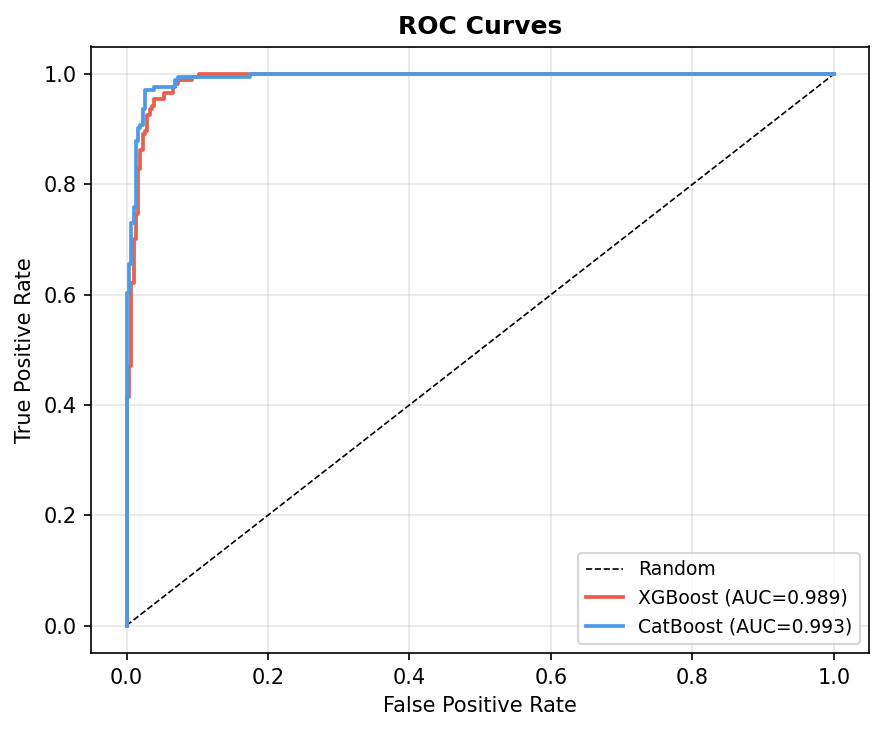

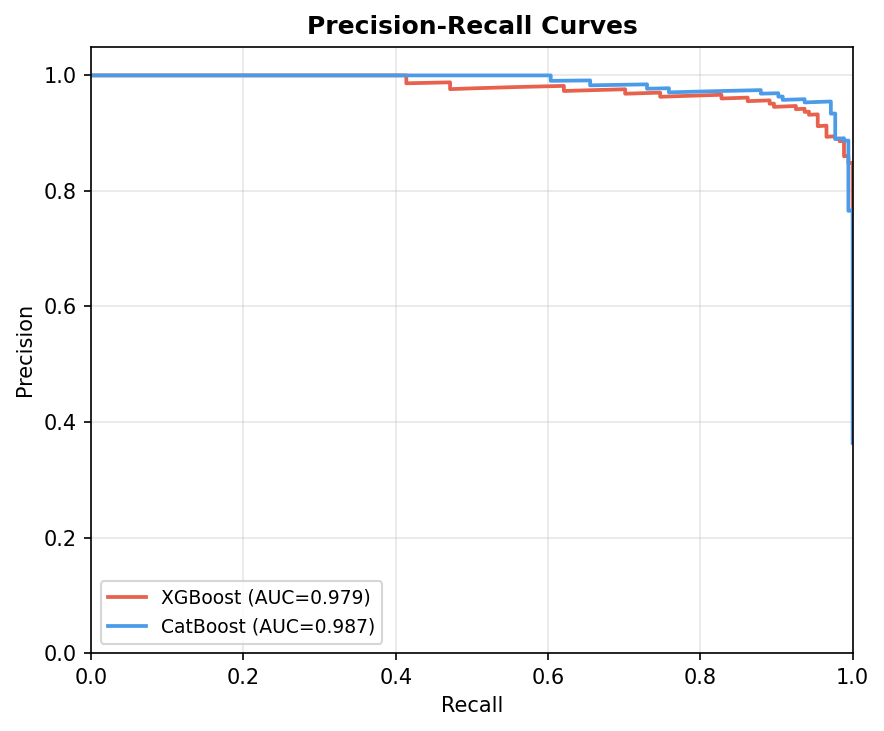

In [15]:
# Build curve data from test-set predictions and display ROC + PR curves
roc_data_fixed = {}
pr_data_fixed = {}
for name in MODEL_NAMES:
    y_true = fixed_results[name]["test"]["y_true"]
    y_proba = fixed_results[name]["test"]["y_proba"]
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    prec, rec, _ = precision_recall_curve(y_true, y_proba)
    roc_data_fixed[name] = (fpr, tpr, fixed_results[name]["test"]["roc_auc"])
    pr_data_fixed[name] = (prec, rec, fixed_results[name]["test"]["pr_auc"])

plot_roc_curves(roc_data_fixed, suffix="_fixed")
plot_pr_curves(pr_data_fixed, suffix="_fixed")
display(Image(str(PLOTS_DIR / "fig_roc_curves_fixed.png")))
display(Image(str(PLOTS_DIR / "fig_pr_curves_fixed.png")))

INFO:train_classifiers:Saved -> c:\Users\moris\OneDrive\Documents\hackathon_blr\drowsiness-detection\notebooks\..\outputs\classifier_plots\fig_feature_importance.png


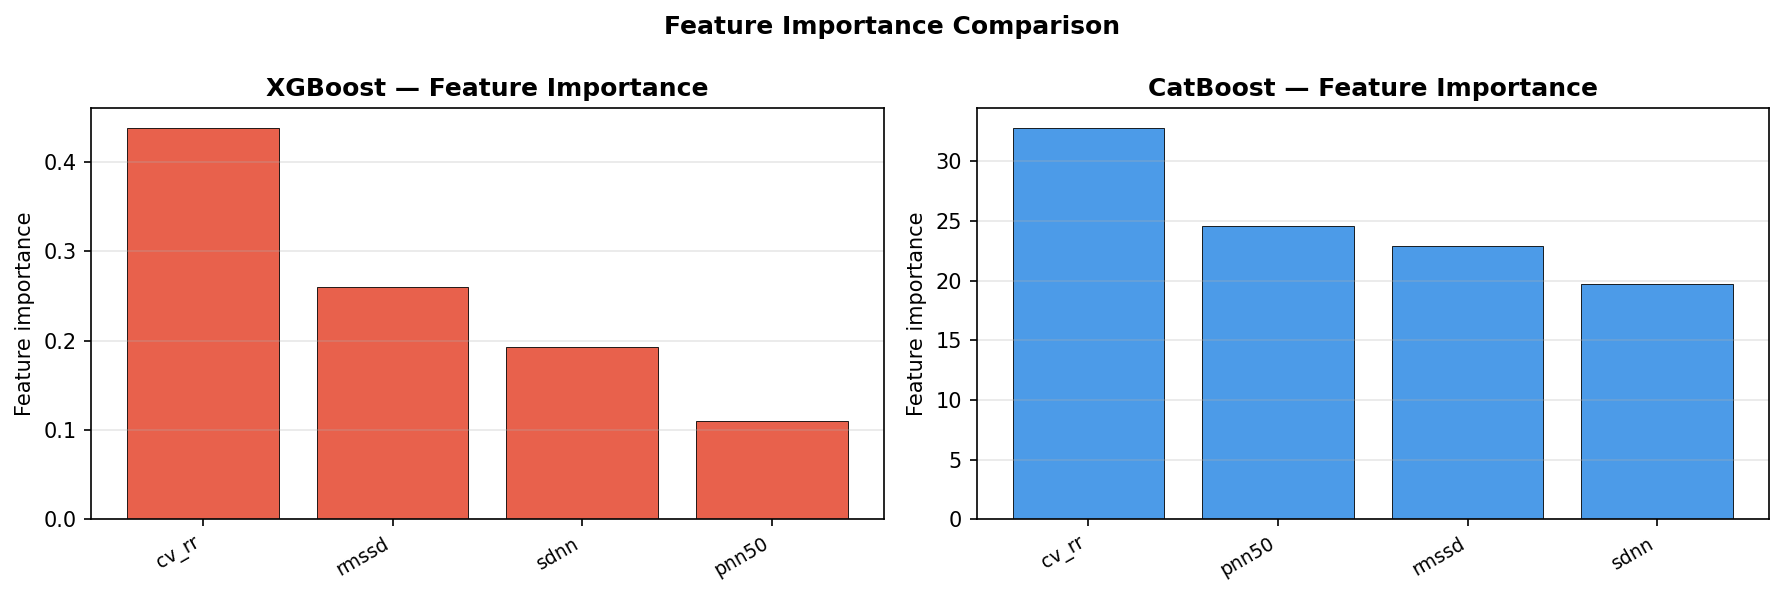

In [16]:
# Feature importance for both fitted models
fitted_models_fixed = {name: fixed_results[name]["model"] for name in MODEL_NAMES}
plot_feature_importance(fitted_models_fixed, loader.feature_cols)
display(Image(str(PLOTS_DIR / "fig_feature_importance.png")))

### Leave-One-Subject-Out Cross-Validation

Each of the 24 subjects is held out once. Predictions are pooled across all folds for aggregate evaluation. Folds where the test set contains only one class are skipped automatically.

In [17]:
# `loader.df` is available after prepare() — no extra load_data() call needed
loso_results = _run_loso(loader)

INFO:dataloader:Creating LOSO folds with 24 subjects...
INFO:dataloader:Fold  1/24: test_subject=ddd_01M, train_samples=2307, test_samples=234
INFO:dataloader:Fold  2/24: test_subject=ddd_02F, train_samples=2305, test_samples=236
INFO:dataloader:Fold  3/24: test_subject=ddd_03F, train_samples=2306, test_samples=235
INFO:dataloader:Fold  4/24: test_subject=ddd_04M, train_samples=2314, test_samples=227
INFO:dataloader:Fold  5/24: test_subject=ddd_05M, train_samples=2309, test_samples=232
INFO:dataloader:Fold  6/24: test_subject=ddd_06M, train_samples=2307, test_samples=234
INFO:dataloader:Fold  7/24: test_subject=ddd_07F, train_samples=2307, test_samples=234
INFO:dataloader:Fold  8/24: test_subject=ddd_08M, train_samples=2309, test_samples=232
INFO:dataloader:Fold  9/24: test_subject=ddd_09M, train_samples=2309, test_samples=232
INFO:dataloader:Fold 10/24: test_subject=ddd_10M, train_samples=2309, test_samples=232
INFO:dataloader:Fold 11/24: test_subject=drozy_s01, train_samples=2523, te

In [20]:
# Per-fold precision/recall/F1 for each model
for name in MODEL_NAMES:
    fold_df = pd.DataFrame(loso_results[name]["fold_records"])
    print(f"\n{name} — per-fold metrics:")
    cols = ["fold", "held_out_subject", "n_test", "precision", "recall", "f1", "roc_auc"]
    print(fold_df[cols].to_string(index=False))

# Aggregate metrics (pooled predictions at optimal threshold)
print("\n")
print(_format_comparison_loso(loso_results))


XGBoost — per-fold metrics:
 fold held_out_subject  n_test  precision   recall       f1  roc_auc
    1          ddd_01M     234   0.989899 1.000000 0.994924 0.999475
    2          ddd_02F     236   0.949495 0.862385 0.903846 0.981579
    3          ddd_03F     235   0.903226 0.976744 0.938547 0.987201
    4          ddd_04M     227   0.967391 0.978022 0.972678 0.993778
    5          ddd_05M     232   0.833333 0.942029 0.884354 0.969236
    6          ddd_06M     234   0.910112 0.861702 0.885246 0.973708
    7          ddd_07F     234   0.825581 0.959459 0.887500 0.978885
    8          ddd_08M     232   0.984848 0.915493 0.948905 0.993351
    9          ddd_09M     232   0.904110 0.891892 0.897959 0.980243
   10          ddd_10M     232   0.835294 0.876543 0.855422 0.955686
   11        drozy_s01      18   0.888889 1.000000 0.941176 0.987500
   12        drozy_s02      18   1.000000 1.000000 1.000000 1.000000
   13        drozy_s03      18   0.666667 1.000000 0.800000 0.916667
   14

INFO:train_classifiers:Saved -> c:\Users\moris\OneDrive\Documents\hackathon_blr\drowsiness-detection\notebooks\..\outputs\classifier_plots\fig_roc_curves_loso.png
INFO:train_classifiers:Saved -> c:\Users\moris\OneDrive\Documents\hackathon_blr\drowsiness-detection\notebooks\..\outputs\classifier_plots\fig_pr_curves_loso.png


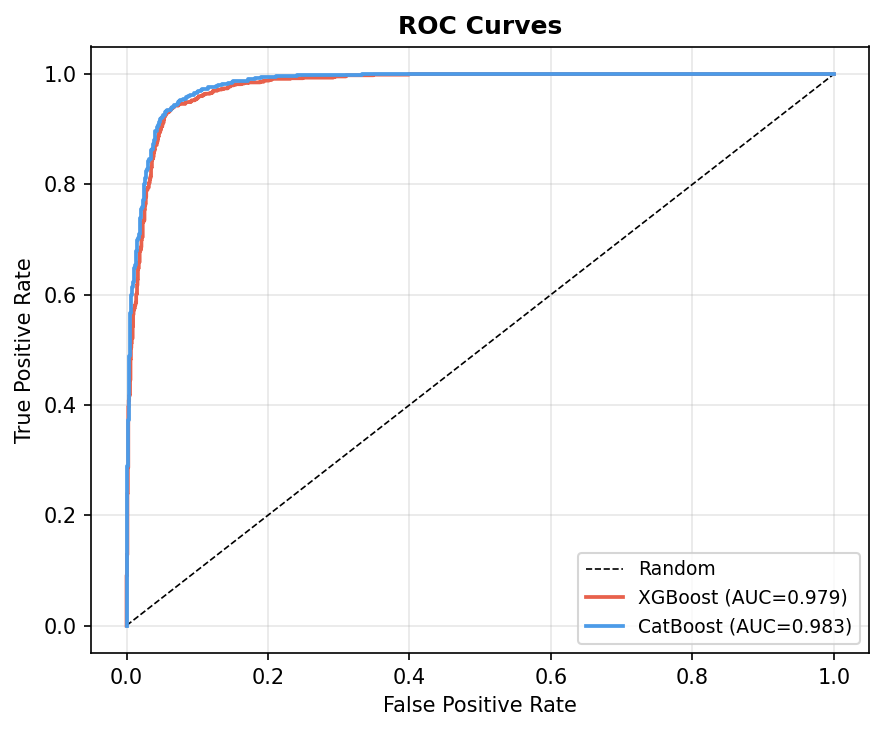

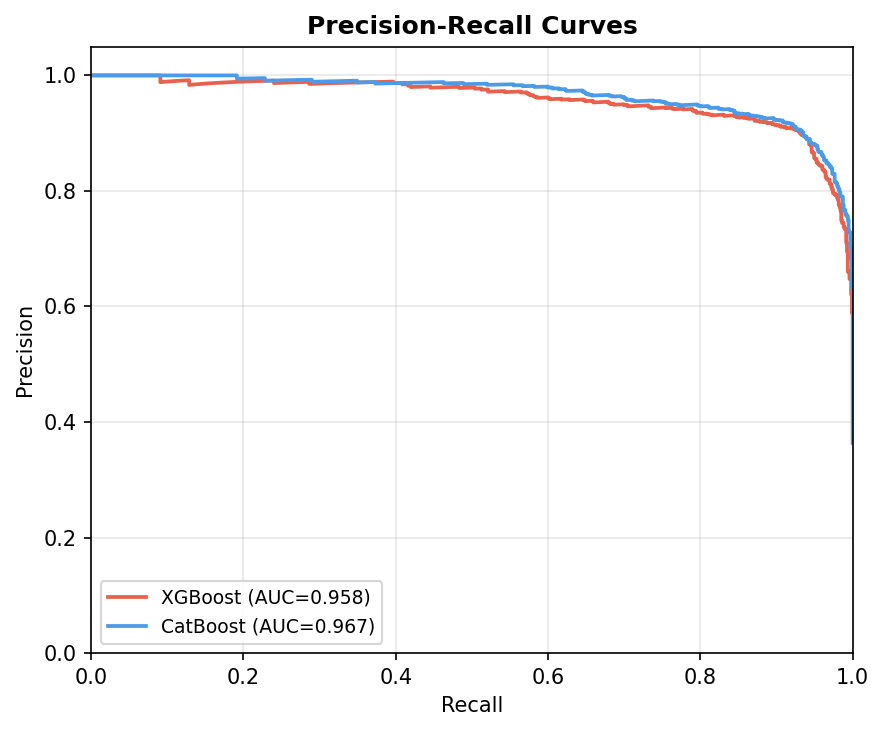

In [21]:
# LOSO pooled ROC + PR curves
roc_data_loso = {}
pr_data_loso = {}
for name in MODEL_NAMES:
    r = loso_results[name]
    fpr, tpr, _ = roc_curve(r["y_true"], r["y_proba"])
    prec, rec, _ = precision_recall_curve(r["y_true"], r["y_proba"])
    roc_data_loso[name] = (fpr, tpr, r["overall"]["roc_auc"])
    pr_data_loso[name] = (prec, rec, r["overall"]["pr_auc"])

plot_roc_curves(roc_data_loso, suffix="_loso")
plot_pr_curves(pr_data_loso, suffix="_loso")
display(Image(str(PLOTS_DIR / "fig_roc_curves_loso.png")))
display(Image(str(PLOTS_DIR / "fig_pr_curves_loso.png")))

### Results Summary

Results are compared across two evaluation protocols:

- **Fixed Split**: 18 train / 3 val / 3 test subjects. Metrics at threshold = 0.5.
- **LOSO-CV**: 24 folds, pooled predictions. Threshold optimised for max precision subject to recall ≥ 0.30.

The code cell below identifies the better-performing model on each protocol.

In [22]:
# Identify the better-performing model on each evaluation protocol
print("=== Fixed Split — Test Set ===")
best_fixed = max(MODEL_NAMES, key=lambda n: fixed_results[n]["test"]["f1"])
for name in MODEL_NAMES:
    m = fixed_results[name]["test"]
    print(
        f"  {name:10s}: Prec={m['precision']:.4f}  Rec={m['recall']:.4f}  "
        f"F1={m['f1']:.4f}  ROC-AUC={m['roc_auc']:.4f}  PR-AUC={m['pr_auc']:.4f}"
    )
print(f"\n  Best (F1): {best_fixed}")

print("\n=== LOSO-CV — Pooled (optimal threshold) ===")
best_loso = max(MODEL_NAMES, key=lambda n: loso_results[n]["overall"]["f1"])
for name in MODEL_NAMES:
    m = loso_results[name]["overall"]
    thr = loso_results[name]["opt_threshold"]
    print(
        f"  {name:10s}: Prec={m['precision']:.4f}  Rec={m['recall']:.4f}  "
        f"F1={m['f1']:.4f}  ROC-AUC={m['roc_auc']:.4f}  PR-AUC={m['pr_auc']:.4f}  "
        f"threshold={thr:.4f}"
    )
print(f"\n  Best (F1): {best_loso}")

=== Fixed Split — Test Set ===
  XGBoost   : Prec=0.9274  Rec=0.9540  F1=0.9405  ROC-AUC=0.9894  PR-AUC=0.9785
  CatBoost  : Prec=0.9548  Rec=0.9713  F1=0.9630  ROC-AUC=0.9930  PR-AUC=0.9871

  Best (F1): CatBoost

=== LOSO-CV — Pooled (optimal threshold) ===
  XGBoost   : Prec=0.9892  Rec=0.3968  F1=0.5664  ROC-AUC=0.9786  PR-AUC=0.9580  threshold=0.9991
  CatBoost  : Prec=0.9908  Rec=0.3492  F1=0.5164  ROC-AUC=0.9827  PR-AUC=0.9669  threshold=0.9954

  Best (F1): XGBoost


## Threshold Adjustment to Minimize False Positive Rate

In [23]:
import sys

sys.path.insert(0, "../src")
from sklearn.metrics import confusion_matrix

from threshold_utils import find_threshold_for_fpr

target_fpr = 0.05  # Allow max 5% false positive rate

print(f"Testing threshold adjustment for target FPR = {target_fpr:.2f}\n")

for model_name, model in [("XGBoost", xgb_model_best), ("CatBoost", cat_model_best)]:
    print(f"--- {model_name} ---")
    y_proba_test = model.predict_proba(X_test)[:, 1]

    new_threshold = find_threshold_for_fpr(y_test, y_proba_test, target_fpr)
    y_pred_new = (y_proba_test >= new_threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred_new)
    print(f"New Threshold: {new_threshold:.4f}")
    print(f"Confusion Matrix:\n{cm}\n")

Testing threshold adjustment for target FPR = 0.05

--- XGBoost ---
New Threshold: 0.5336
Confusion Matrix:
[[292  12]
 [  5 169]]

--- CatBoost ---
New Threshold: 0.2513
Confusion Matrix:
[[290  14]
 [  2 172]]



In [31]:
import json

import numpy as np

from threshold_utils import find_threshold_for_fpr

# Collect LOSO optimal thresholds
optimal_thresholds = {
    "loso": {
        "XGBoost": float(loso_results["XGBoost"]["opt_threshold"]),
        "CatBoost": float(loso_results["CatBoost"]["opt_threshold"]),
    },
    "fpr_05": {},
}

# Recalculate FPR=0.05 thresholds
target_fpr = 0.05
X_test = splits_alt["test"][loader.feature_cols].values
y_test = splits_alt["test"][loader.target_col].values

for model_name, model in [("XGBoost", xgb_model_best), ("CatBoost", cat_model_best)]:
    y_proba_test = model.predict_proba(X_test)[:, 1]
    threshold = find_threshold_for_fpr(y_test, y_proba_test, target_fpr)
    optimal_thresholds["fpr_05"][model_name] = float(threshold)

# Save to JSON
results_file = "../outputs/optimal_thresholds.json"
with open(results_file, "w") as f:
    json.dump(optimal_thresholds, f, indent=2)

print(f"✓ Optimal thresholds saved to: {results_file}")

✓ Optimal thresholds saved to: ../outputs/optimal_thresholds.json


In [33]:
from sklearn.metrics import f1_score, precision_score, recall_score

print("Metrics Comparison Before/After Optimal Thresholding (FPR=0.05):")

for model_name, model in [("XGBoost", xgb_model_best), ("CatBoost", cat_model_best)]:
    y_proba_test = model.predict_proba(X_test)[:, 1]

    # Default threshold (0.5)
    y_pred_05 = (y_proba_test >= 0.5).astype(int)

    # Optimal threshold (FPR=0.05)
    threshold = optimal_thresholds["fpr_05"][model_name]
    y_pred_opt = (y_proba_test >= threshold).astype(int)

    print(f"\n--- {model_name} ---")
    print(
        f"Threshold 0.5:  F1={f1_score(y_test, y_pred_05):.4f},"
        f"Prec={precision_score(y_test, y_pred_05):.4f}, "
        f"Rec={recall_score(y_test, y_pred_05):.4f}"
    )
    print(
        f"Threshold {threshold:.4f}: F1={f1_score(y_test, y_pred_opt):.4f}, "
        f"Prec={precision_score(y_test, y_pred_opt):.4f}, "
        f"Rec={recall_score(y_test, y_pred_opt):.4f}"
    )

Metrics Comparison Before/After Optimal Thresholding (FPR=0.05):

--- XGBoost ---
Threshold 0.5:  F1=0.9415,Prec=0.9135, Rec=0.9713
Threshold 0.5336: F1=0.9521, Prec=0.9337, Rec=0.9713

--- CatBoost ---
Threshold 0.5:  F1=0.9513,Prec=0.9486, Rec=0.9540
Threshold 0.2513: F1=0.9556, Prec=0.9247, Rec=0.9885
